In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500", output_dir="./dataset")

c:\Coding\School\Research\bipolar-cell-simulation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import cv2
import glob
import numpy as np
from matplotlib import pyplot as plt

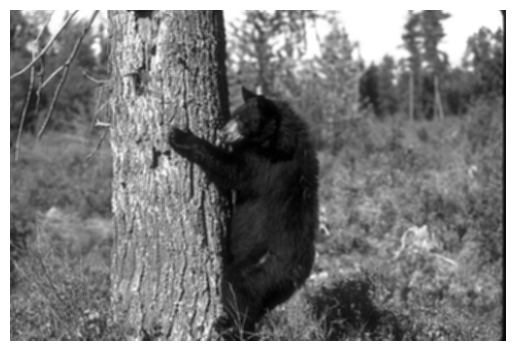

In [40]:
directory = "./dataset/images/test"

images = []
for filename in glob.iglob(f'{directory}/*.jpg'):
    # Load the image in as grayscale
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    # Apply gaussian blur filter to image
    image = cv2.GaussianBlur(image, (3,3), 2)
    images.append(image)

# Test image output
plt.imshow(images[1], cmap='gray')
plt.axis('off')
plt.show()


(np.float64(-0.5), np.float64(480.5), np.float64(320.5), np.float64(-0.5))

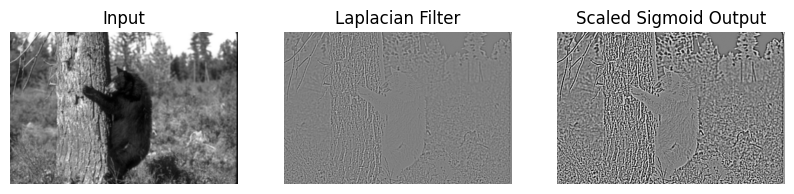

In [65]:
laplacian = cv2.Laplacian(images[1], cv2.CV_64F, ksize=3)

# Used to lessen the contrast in the final image, creating neutral values
# Without this, the final image is too noisy
scaling_factor = 0.02

def sigmoid(x):
    return 1 / (1 + np.exp(-(x*scaling_factor)))

final_img = sigmoid(laplacian)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].imshow(images[1], cmap='gray')
ax[0].set_title('Input')
ax[0].axis('off')

ax[1].imshow(laplacian, cmap='gray')
ax[1].set_title('Laplacian Filter')
ax[1].axis('off')

ax[2].imshow(final_img, cmap='gray')
ax[2].set_title('Scaled Sigmoid Output')
ax[2].axis('off')

